# Red Neuronal con Pytorch (Dataset de Clasificación Binaria)

# Preparación de Datos

In [ ]:
# Imports
import os
import numpy as np
import pandas as pd
import torch
import torchvision
from tqdm import tqdm
from matplotlib import pyplot
from scipy import optimize
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/SIS420/datasets/datasets_tareas/heart_2022_no_nans.csv')

print(data.head())
print(data.dtypes)
print(data.isnull().sum())

# Rellenar NaN numéricos con la media
num_cols = data.select_dtypes(include=['float64','int64']).columns
for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())

print(data.isnull().sum().sum())

# Y elegida HadHeartAttack, convertir yes/no a 1/0
data['HadHeartAttack'] = data['HadHeartAttack'].map({'Yes':1, 'No':0})

print(data['HadHeartAttack'].head())

# Convertir columnas categóricas a dummies
print(data.select_dtypes(include=['object']).columns)
data = pd.get_dummies(data)

for col in data.columns:
    print(col, data[col].dtype)

X = data.drop('HadHeartAttack', axis=1)
y = data['HadHeartAttack']

X = X.astype(float).values
y = y.astype(float).values

print("X:", X.shape)
print("y:", y.shape)

     State     Sex GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
0  Alabama  Female     Very good                 4.0               0.0   
1  Alabama    Male     Very good                 0.0               0.0   
2  Alabama    Male     Very good                 0.0               0.0   
3  Alabama  Female          Fair                 5.0               0.0   
4  Alabama  Female          Good                 3.0              15.0   

                                     LastCheckupTime PhysicalActivities  \
0  Within past year (anytime less than 12 months ...                Yes   
1  Within past year (anytime less than 12 months ...                Yes   
2  Within past year (anytime less than 12 months ...                 No   
3  Within past year (anytime less than 12 months ...                Yes   
4  Within past year (anytime less than 12 months ...                Yes   

   SleepHours            RemovedTeeth HadHeartAttack  ... HeightInMeters  \
0         9.0            Non

## Gráfico de clasificación

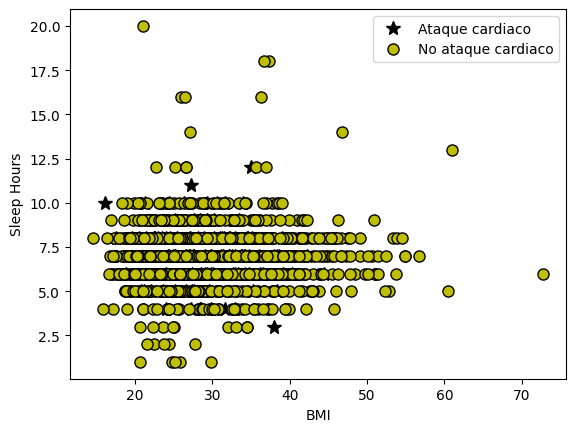

In [ ]:
# Tomar una muestra de 2000 filas
sample = data.sample(n=2000, random_state=1)

X_plot = sample[['BMI', 'SleepHours']].values
y_plot = sample['HadHeartAttack'].values

def plotData(X, y):
    fig = pyplot.figure()
    pos = y == 1
    neg = y == 0
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)
    pyplot.xlabel("BMI")
    pyplot.ylabel("Sleep Hours")

plotData(X_plot, y_plot)
pyplot.legend(['Ataque cardiaco', 'No ataque cardiaco'])
pyplot.show()

## Procesamiento

In [ ]:
#  Normalización
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # evitar division por cero en columnas constantes (dummies)
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

Media calculada: [4.11902594e+00 4.16713952e+00 7.02133143e+00 1.70515043e+00
 8.36151787e+01 2.86681358e+01 7.73101593e-03 1.30272902e-02
 2.22012666e-02 1.19501508e-02 2.07135947e-02 2.09696694e-02
 2.05388136e-02 8.75937924e-03 7.01156807e-03 2.97331133e-02
 2.02339628e-02 6.29618489e-03 2.27459333e-02 1.40963003e-02
 1.05966133e-02 2.23638536e-02 2.30548488e-02 2.49774410e-02
 9.80806595e-03 1.22346782e-02 2.44409037e-02 3.72527660e-02
 2.22134606e-02 2.18273163e-02 3.72365073e-02 9.90968287e-03
 1.70513206e-02 1.73317833e-02 2.07583062e-02 7.19041387e-03
 1.52669273e-02 1.61245742e-02 1.20639618e-02 3.62691141e-02
 1.03689914e-02 1.01535635e-02 3.65617709e-02 1.19542155e-02
 1.23932006e-02 1.10925039e-02 1.45881263e-02 1.26492753e-02
 2.22378486e-02 1.79049028e-02 1.10762452e-02 3.01111283e-02
 2.18395103e-02 1.96933608e-02 3.02005512e-03 2.26199283e-02
 6.09701571e-02 1.20883498e-02 2.49002122e-02 9.79587191e-03
 5.19510450e-01 4.80489550e-01 1.68785718e-01 1.24618937e-01
 3.1464

In [ ]:
# Split train/test
m = y.shape[0]
split = int(m * 0.80)

X_train = X_norm[:split].astype(np.float32)
X_test  = X_norm[split:].astype(np.float32)
y_train = y[:split].astype(np.float32)
y_test  = y[split:].astype(np.float32)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 196817  |  Test: 49205


In [ ]:
# Convertir a tensores

# convertimos datos a tensores y copiamos en gpu
X_t = torch.from_numpy(X_train).float().to(device)
Y_t = torch.from_numpy(y_train).float().to(device)

## Modelos

In [ ]:
# Modelo Sequential
D_in  = X_train.shape[1]
H1    = 128
H2    = 64
D_out = 1  # salida binaria: probabilidad de ataque cardiaco

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H1),
    torch.nn.ReLU(),
    torch.nn.Linear(H1, H2),
    torch.nn.ReLU(),
    torch.nn.Linear(H2, D_out),
    torch.nn.Sigmoid()  # salida entre 0 y 1, equivalente al sigmoid del código original
)

# probar que el modelo recibe los datos en las dimensiones correctas
x_prueba = torch.randn(500, D_in)
outputs = model(x_prueba)
outputs.shape

torch.Size([500, 1])

In [ ]:
# Modelo personalizado
class ModeloPersonalizado(torch.nn.Module):

    def __init__(self, D_in, H1, H2, D_out):
        super(ModeloPersonalizado, self).__init__()
        self.fc1   = torch.nn.Linear(D_in, H1)
        self.relu1 = torch.nn.ReLU()
        self.fc2   = torch.nn.Linear(H1, H2)
        self.relu2 = torch.nn.ReLU()
        self.fc3   = torch.nn.Linear(H2, D_out)
        self.sigmoid = torch.nn.Sigmoid()  # equivalente a sigmoid() del código original

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

## Dataset y dataloader

In [ ]:
# Dataset personalizado
class DatasetPersonalizado(torch.utils.data.Dataset):
    # constructor
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float().to(device)
        self.Y = torch.from_numpy(Y).float().to(device)
    # devolvemos el número de datos en el dataset
    def __len__(self):
        return len(self.X)
    # devolvemos el elemento ix del dataset
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

In [ ]:
# DataLoader
dataloader = {
    'train': torch.utils.data.DataLoader(
                DatasetPersonalizado(X_train, y_train),
                batch_size=256, shuffle=True),
    'test':  torch.utils.data.DataLoader(
                DatasetPersonalizado(X_test, y_test),
                batch_size=256, shuffle=False)
}

x, y_b = next(iter(dataloader['train']))
print(x.shape, y_b.shape)

torch.Size([256, 154]) torch.Size([256])


In [ ]:
# Función fit
train_losses = []

def fit(model, dataloader, epochs=200, PATH="./checkpoint.pt"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.BCELoss()  # equivalente a cross_entropy binaria del código original
    best_loss = float("inf")
    for epoch in range(1, epochs+1):
        model.train()
        train_loss = []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y.unsqueeze(1))
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            bar.set_description(f"loss {np.mean(train_loss):.5f}")
        bar = tqdm(dataloader['test'])
        val_loss = []
        model.eval()
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y.unsqueeze(1))
                val_loss.append(loss.item())
                bar.set_description(f"val_loss {np.mean(val_loss):.5f}")
        # guardar modelo si es el mejor
        val_loss = np.mean(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), PATH)
            print(f"Best model saved at epoch {epoch} with val_loss {val_loss:.5f}")
        print(f"Epoch {epoch}/{epochs} loss {np.mean(train_loss):.5f} val_loss {val_loss:.5f}")
        train_losses.append(np.mean(train_loss))
    # cargar el mejor modelo al final del entrenamiento
    model.load_state_dict(torch.load(PATH))

In [ ]:
# Función evaluate
def evaluate(model, dataloader):
    model.eval()
    model.to(device)
    bar = tqdm(dataloader['test'])
    acc = []
    with torch.no_grad():
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            # umbral 0.5 igual que en el código original: sigmoid >= 0.5
            pred = (y_hat.squeeze() >= 0.5).float()
            acc.append((pred == y).float().mean().item())
            bar.set_description(f"acc {np.mean(acc):.5f}")

## Entrenar y evaluar

In [ ]:
model = ModeloPersonalizado(D_in, H1, H2, D_out)
fit(model, dataloader)
evaluate(model, dataloader)

val_loss 0.18990: 100%|██████████| 193/193 [00:00<00:00, 239.29it/s]


Best model saved at epoch 1 with val_loss 0.18990
Epoch 1/200 loss 0.15688 val_loss 0.18990


val_loss 0.17935: 100%|██████████| 193/193 [00:00<00:00, 300.39it/s]


Best model saved at epoch 2 with val_loss 0.17935
Epoch 2/200 loss 0.14299 val_loss 0.17935


val_loss 0.16151: 100%|██████████| 193/193 [00:00<00:00, 296.11it/s]


...

val_loss 3.99018: 100%|██████████| 193/193 [00:01<00:00, 176.50it/s]


Epoch 199/200 loss 0.01071 val_loss 3.99018


val_loss 3.93134: 100%|██████████| 193/193 [00:00<00:00, 240.48it/s]


Epoch 200/200 loss 0.01106 val_loss 3.93134


acc 0.95014: 100%|██████████| 193/193 [00:00<00:00, 230.93it/s]


## Gráfica de convergencia

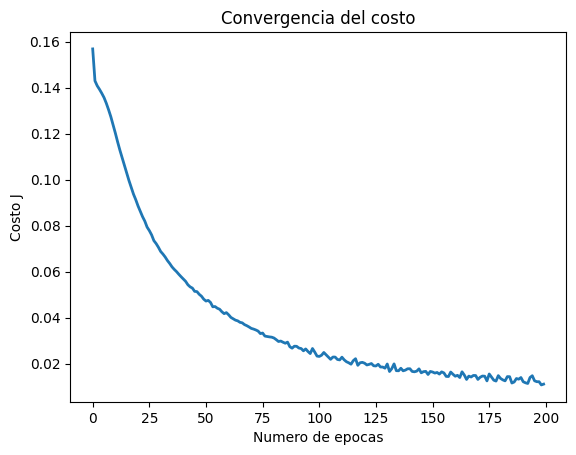

In [ ]:
pyplot.plot(np.arange(len(train_losses)), train_losses, lw=2)
pyplot.xlabel('Numero de epocas')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo')
pyplot.show()

## Guardar modelo

In [ ]:
# guardar solo pesos
PATH = './checkpoint.pt'
torch.save(model.state_dict(), PATH)

# cargar pesos
model.load_state_dict(torch.load(PATH, weights_only=True))
model.eval()

# guardar modelo completo
torch.save(model, 'model.pt')

# cargar modelo completo
model = torch.load('model.pt', weights_only=False)
model.eval()

ModeloPersonalizado(
  (fc1): Linear(in_features=154, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

## Predicción ejemplo individual

In [ ]:
# probar con un ejemplo del dataset
model.to(device)
model.eval()

ejemplo = torch.tensor(X_test[0]).unsqueeze(0).to(device)

with torch.no_grad():
    prob = model(ejemplo).item()

pred = prob >= 0.5

print("Probabilidad de ataque cardiaco:", round(prob * 100, 2), "%")

if pred:
    print("Predicción: Ataque cardiaco")
else:
    print("Predicción: No ataque cardiaco")

Probabilidad de ataque cardiaco: 0.98 %
Predicción: No ataque cardiaco


## Accuracy del modelo

In [ ]:
model.eval()
model.to(device)

with torch.no_grad():
    X_test_t = torch.from_numpy(X_test).float().to(device)
    y_pred_prob = model(X_test_t).cpu().numpy().flatten()

predicciones = (y_pred_prob >= 0.5).astype(float)
accuracy = np.mean(predicciones == y_test) * 100

print("Accuracy del modelo:", round(accuracy, 2), "%")

Accuracy del modelo: 95.02 %


## TorchScript

In [ ]:
x = torch.randn(1, D_in)
traced_model = torch.jit.trace(model.cpu(), x)
traced_model.save('model.zip')

loaded_model = torch.jit.load('model.zip')

scripted_model = torch.jit.script(model.cpu())
scripted_model.save('model.zip')

loaded_model = torch.jit.load('model.zip')

## Export ONNX

In [ ]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 21.8 MB/s eta 0:00:00


In [ ]:
x = torch.randn(1, D_in)

torch.onnx.export(model.cpu(),
                  x,
                  "model.onnx",
                  export_params=True,
                  opset_version=10,
                  do_constant_folding=True,
                  input_names=['input'],
                  output_names=['output'],
                  dynamic_axes={'input':  {0: 'batch_size'},
                                'output': {0: 'batch_size'}})

/tmp/ipykernel_1495/2817503493.py:3: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model.cpu(),
W0330 16:07:40.596000 1495 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 10 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0330 16:07:41.317000 1495 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'i

[torch.onnx] Obtain model graph for `ModeloPersonalizado([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ModeloPersonalizado([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch_size,154]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,1]>
            ),
            initializers=(
                %"fc1.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"fc2.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"fc3.weight"<FLOAT,[1,64]>{TorchTensor(...)},
                %"fc3.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([-0.0611], requires_grad=True), name='fc3.bias')},
                %"fc1.weight"<FLOAT,[128,154]>{TorchTensor(...)},
                %"fc2.weight"<FLOAT,[64,128]>{TorchTensor(...)}
            ),
        ) {
            0 |  # node_linear
 

## Evaluación sobre datos de test

In [ ]:
model.to(device)
model.eval()
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test).float().to(device)
    y_pred_pytorch = model(X_test_t).cpu().numpy().flatten()

predicciones = (y_pred_pytorch >= 0.5).astype(float)

print("Primeras 10 predicciones vs valores reales:")
print(f"{'Real':>10}  {'Prob':>10}  {'Predicho':>10}")
for real, prob, pred in zip(y_test[:10], y_pred_pytorch[:10], predicciones[:10]):
    print(f"{int(real):>10}  {prob:>10.4f}  {int(pred):>10}")

accuracy = np.mean(predicciones == y_test) * 100
print(f"\nAccuracy del modelo: {accuracy:.2f}%")
print('Accuracy esperado (aproximado): > 90%')

Primeras 10 predicciones vs valores reales:
      Real        Prob    Predicho
         0      0.0098           0
         0      0.0151           0
         0      0.0040           0
         0      0.0115           0
         0      0.0486           0
         0      0.0011           0
         0      0.0046           0
         0      0.0005           0
         0      0.0303           0
         0      0.0188           0

Accuracy del modelo: 95.02%
Accuracy esperado (aproximado): > 90%


## Evaluar riesgo

In [ ]:
def evaluar_riesgo(model, mu, sigma, columnas):

    print("\n=== Evaluación de Riesgo de Ataque Cardíaco ===\n")

    x_input = np.zeros(len(columnas), dtype=np.float32)

    def set_val(col, val):
        if col in columnas:
            x_input[columnas.index(col)] = val

    bmi    = float(input("1) BMI (ej: 26): "))
    sleep  = float(input("2) Horas de sueño por noche: "))
    phys   = float(input("3) Días de mala salud física en el último mes: "))
    mental = float(input("4) Días de mala salud mental en el último mes: "))
    peso   = float(input("5) Peso en kg: "))
    altura = float(input("6) Altura en metros (ej: 1.75): "))

    set_val("BMI", bmi)
    set_val("SleepHours", sleep)
    set_val("PhysicalHealthDays", phys)
    set_val("MentalHealthDays", mental)
    set_val("WeightInKilograms", peso)
    set_val("HeightInMeters", altura)

    fuma   = input("7) ¿Fuma? (s/n): ")
    riesgo = input("8) ¿Tuvo una condición de alto riesgo el último año? (s/n): ")
    covid  = input("9) ¿Tuvo COVID positivo? (s/n): ")
    alcohol = input("10) ¿Consume alcohol regularmente? (s/n): ")

    if fuma.lower() == "s":
        set_val("SmokerStatus_Yes", 1)
    if riesgo.lower() == "s":
        set_val("HighRiskLastYear_Yes", 1)
    if covid.lower() == "s":
        set_val("CovidPos_Yes", 1)
    if alcohol.lower() == "s":
        set_val("AlcoholDrinkers_Yes", 1)

    # normalizar con mu y sigma del entrenamiento
    x_norm = ((x_input - mu) / sigma).astype(np.float32)

    tensor = torch.tensor(x_norm).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        prob = model(tensor).item()

    print("\nProbabilidad estimada de ataque cardíaco:", round(prob * 100, 2), "%")

    if prob >= 0.5:
        print("⚠ Riesgo ALTO de ataque cardíaco")
    else:
        print("✓ Riesgo BAJO de ataque cardíaco")

columnas = data.drop('HadHeartAttack', axis=1).columns.tolist()
evaluar_riesgo(model, mu, sigma, columnas)


=== Evaluación de Riesgo de Ataque Cardíaco ===

1) BMI (ej: 26): 24
2) Horas de sueño por noche: 8
3) Días de mala salud física en el último mes: 2
4) Días de mala salud mental en el último mes: 2
5) Peso en kg: 72
6) Altura en metros (ej: 1.75): 1.69
7) ¿Fuma? (s/n): n
8) ¿Tuvo una condición de alto riesgo el último año? (s/n): n
9) ¿Tuvo COVID positivo? (s/n): n
10) ¿Consume alcohol regularmente? (s/n): n

Probabilidad estimada de ataque cardíaco: 61.04 %
⚠ Riesgo ALTO de ataque cardíaco


## Comparación de resultados

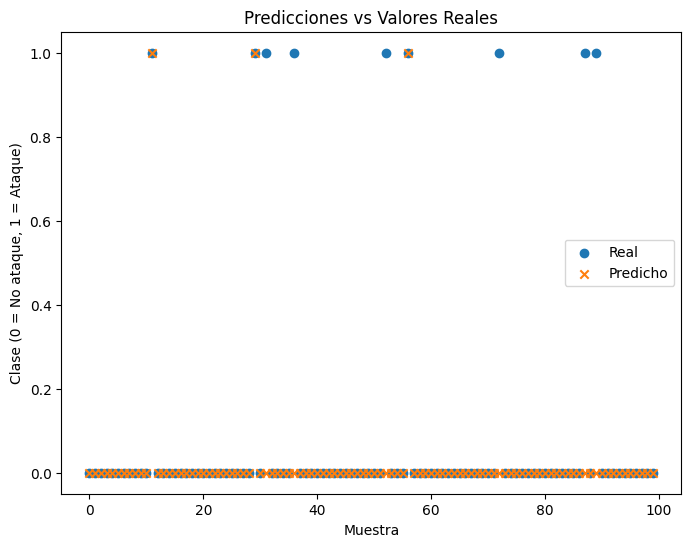

In [ ]:
pyplot.figure(figsize=(8,6))

pyplot.scatter(range(100), y_test[:100], label="Real", marker='o')
pyplot.scatter(range(100), predicciones[:100], label="Predicho", marker='x')

pyplot.xlabel("Muestra")
pyplot.ylabel("Clase (0 = No ataque, 1 = Ataque)")
pyplot.title("Predicciones vs Valores Reales")
pyplot.legend()

pyplot.show()

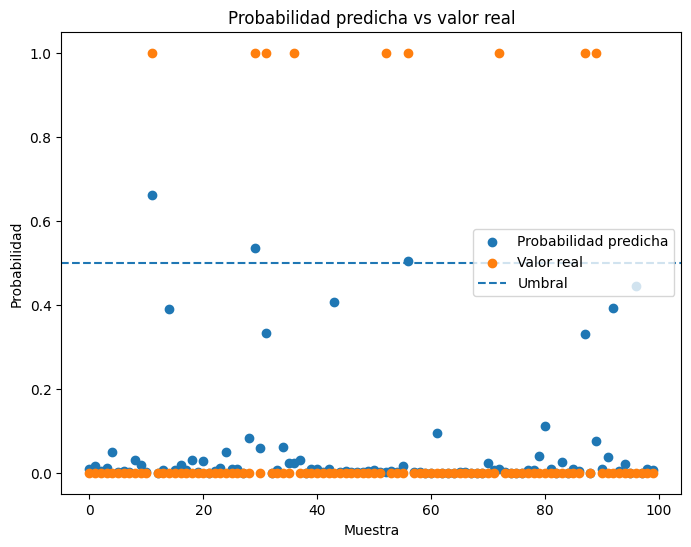

In [ ]:
pyplot.figure(figsize=(8,6))

pyplot.scatter(range(100), y_pred_pytorch[:100], label="Probabilidad predicha")
pyplot.scatter(range(100), y_test[:100], label="Valor real")

pyplot.axhline(0.5, linestyle="--", label="Umbral")

pyplot.xlabel("Muestra")
pyplot.ylabel("Probabilidad")
pyplot.title("Probabilidad predicha vs valor real")
pyplot.legend()

pyplot.show()